# Midterm 2 Deep Learning Project

## SMS Spam Classification

??? notebook SMS ?????????????? `ham` ???? `spam` ??????? ????????? ????? Deep Learning ??????? ?????????. ???? built-in ???????????? ???????????, ????? UCI Machine Learning Repository ???????? ?????? ?????????.

**???????????? ?????????:**

1. Simple Neural Network: MLP + TF-IDF
2. Recurrent Neural Network: BiLSTM


## 1. Dataset source

- Dataset page: https://archive.ics.uci.edu/dataset/228/sms+spam+collection
- Direct download URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
- DOI: https://doi.org/10.24432/C5CC84

??????? TensorFlow, Keras, PyTorch ?????? Scikit-Learn built-in loader ?????? ?????????. `src/data.py` ?????????? ??? ZIP ?????? URL ?????? ?????? ??????, local `data/raw/` ????????? ????????.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "midterm2" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT / "midterm2"
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Admin\Documents\Codex\2026-06-01\midterm-2-deep-learning-project-requirements\outputs\project-1


In [2]:
from config import DATASET_PAGE_URL, DATASET_ZIP_URL
from data import load_raw_dataset, clean_dataset, save_processed_dataset
from eda import run_eda

print("Dataset page:", DATASET_PAGE_URL)
print("Download URL:", DATASET_ZIP_URL)

Dataset page: https://archive.ics.uci.edu/dataset/228/sms+spam+collection
Download URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip


## 2. Load and clean data

??? ??????? raw SMS ????? ???????. ????? ??? ?????? ???????????, duplicate ???????? ???????, label ??????? `ham=0`, `spam=1` ??????? ?????????.


In [3]:
raw_df = load_raw_dataset()
clean_df = clean_dataset(raw_df)
save_processed_dataset(clean_df)

print("Raw shape:", raw_df.shape)
print("Clean shape:", clean_df.shape)
display(raw_df.head())
display(clean_df.head())

Raw shape: (5572, 2)
Clean shape: (5158, 5)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,label,message,label_encoded,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


## 3. Exploratory Data Analysis (EDA)

EDA ????????? dataset size, feature descriptions, class distribution, missing values ???? ????? ???????? ????????. ????????? `results/figures/` ????????? ?????????.


In [4]:
eda_summary = run_eda(raw_df, clean_df)
print(json.dumps(eda_summary, indent=2, ensure_ascii=False))

{
  "raw_rows": 5572,
  "clean_rows": 5158,
  "duplicates_removed": 414,
  "columns": [
    "label",
    "message"
  ],
  "missing_values_raw": {
    "label": 0,
    "message": 0
  },
  "class_distribution_clean": {
    "ham": 4516,
    "spam": 642
  },
  "class_distribution_percent_clean": {
    "ham": 87.55,
    "spam": 12.45
  },
  "message_length": {
    "mean": 79.19794493989919,
    "median": 61.0,
    "min": 2,
    "max": 910
  },
  "word_count": {
    "mean": 15.41721597518418,
    "median": 12.0,
    "min": 1,
    "max": 171
  }
}


class_distribution.png


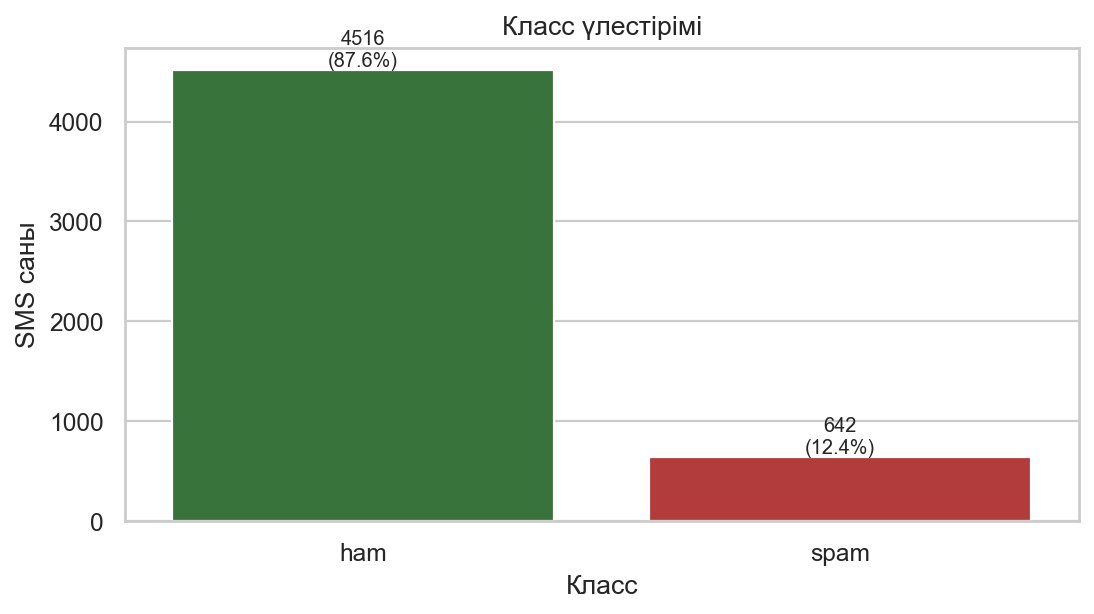

missing_values.png


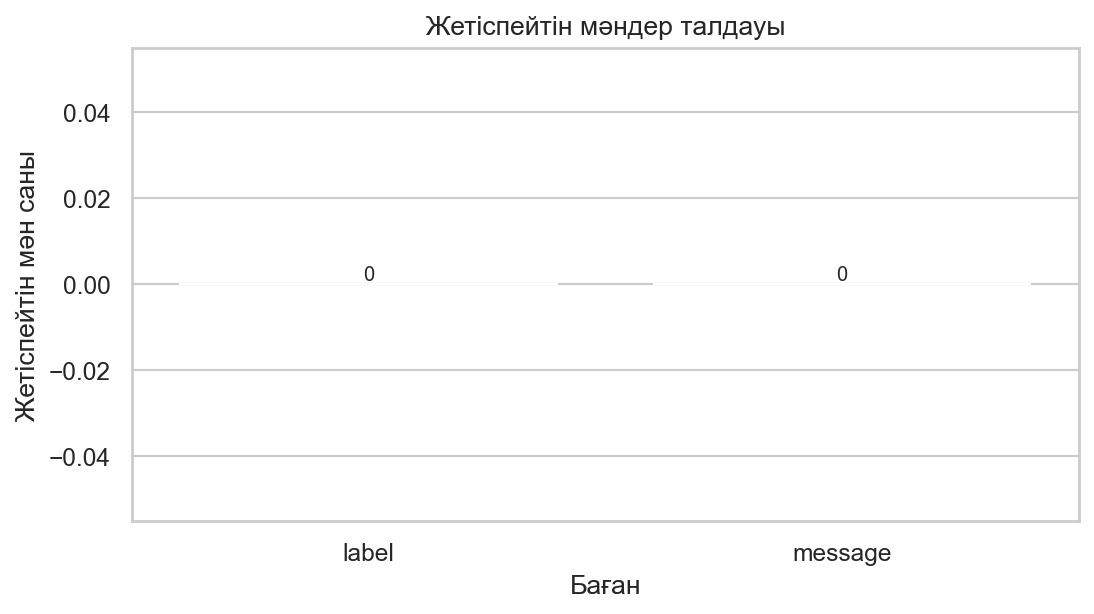

message_length_distribution.png


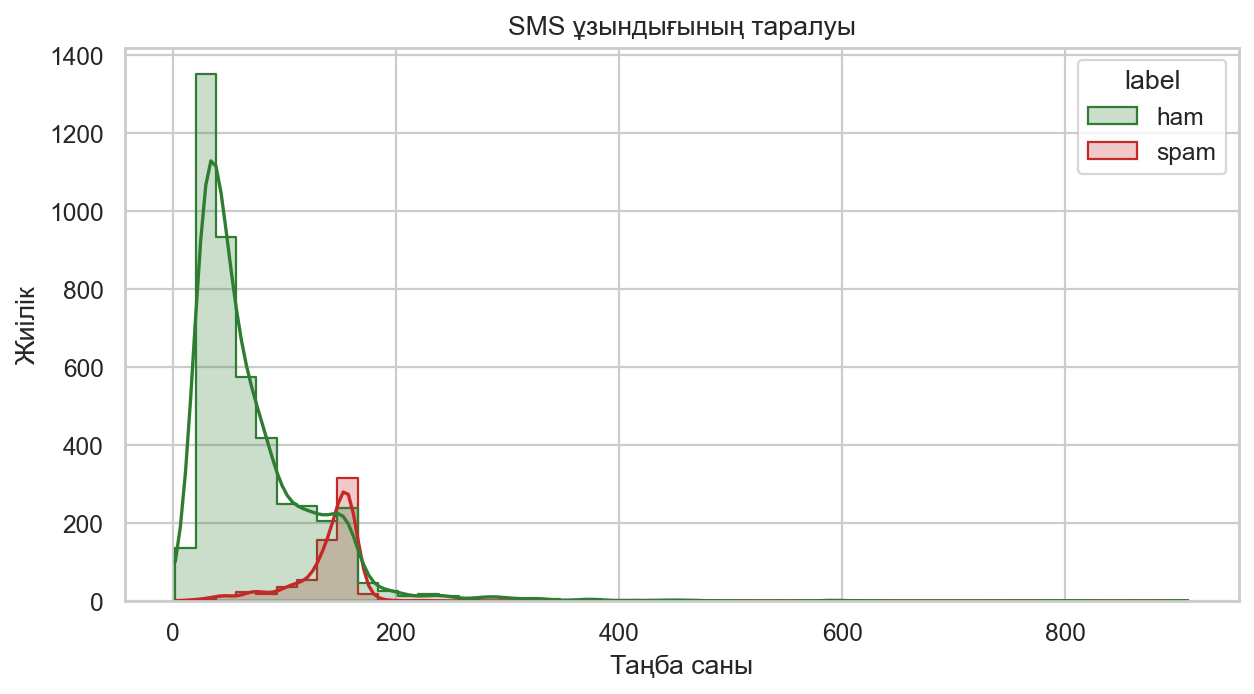

word_count_by_class.png


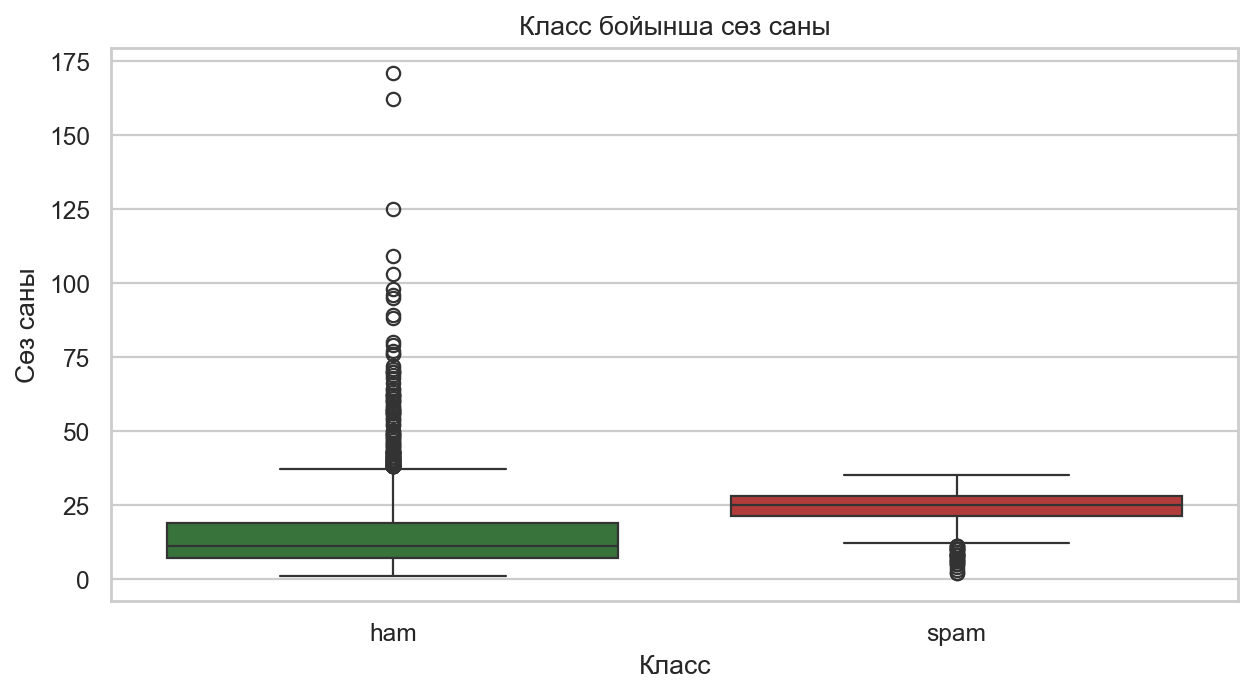

In [5]:
figures = [
    "class_distribution.png",
    "missing_values.png",
    "message_length_distribution.png",
    "word_count_by_class.png",
]

for figure_name in figures:
    print(figure_name)
    display(Image(filename=str(PROJECT_ROOT / "results" / "figures" / figure_name)))

## 4. Data preprocessing

Preprocessing ?????????:

- duplicate ???? ??? ?????????? ???????;
- label encoding: `ham=0`, `spam=1`;
- train/validation/test split: 70% / 15% / 15%;
- MLP ???? TF-IDF feature matrix;
- BiLSTM ???? token sequence matrix;
- validation set ?????? decision threshold ??????.


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from config import MAX_TFIDF_FEATURES
from train import prepare_train_validation_test_split, vectorize_texts
from neural_models import build_text_vectorizer

X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_validation_test_split(clean_df)

sequence_vectorizer = build_text_vectorizer(X_train)
X_train_tokens = vectorize_texts(sequence_vectorizer, X_train)
X_val_tokens = vectorize_texts(sequence_vectorizer, X_val)
X_test_tokens = vectorize_texts(sequence_vectorizer, X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=MAX_TFIDF_FEATURES, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))
print("Token sequence shape:", X_train_tokens.shape)
print("TF-IDF shape:", X_train_tfidf.shape)

Train/Val/Test sizes: 3610 774 774
Token sequence shape: (3610, 80)
TF-IDF shape: (3610, 5000)


## 5. Neural network models

????????? ????? ????? training pipeline ?????????. ?? ??? ???????? ???????, `.keras` ??????????? ???????? ???? ?????? ???????????? `results/` ????? ??????.


In [7]:
from train import train_and_evaluate

payload = train_and_evaluate()
print("Best model by F1:", payload["best_model_by_f1"])


Training mlp_tfidf


Epoch 1/8


57/57 - 2s - 29ms/step - accuracy: 0.8673 - loss: 0.4115 - precision: 0.1053 - recall: 0.0089 - val_accuracy: 0.8747 - val_loss: 0.2151 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


Epoch 2/8


57/57 - 0s - 8ms/step - accuracy: 0.9249 - loss: 0.1462 - precision: 1.0000 - recall: 0.3964 - val_accuracy: 0.9742 - val_loss: 0.1128 - val_precision: 1.0000 - val_recall: 0.7938


...

Epoch 5/8


57/57 - 2s - 41ms/step - accuracy: 0.9989 - loss: 0.0055 - precision: 0.9978 - recall: 0.9933 - val_accuracy: 0.9819 - val_loss: 0.0796 - val_precision: 0.9462 - val_recall: 0.9072


Epoch 6/8


57/57 - 2s - 40ms/step - accuracy: 0.9994 - loss: 0.0021 - precision: 0.9978 - recall: 0.9978 - val_accuracy: 0.9819 - val_loss: 0.0825 - val_precision: 0.9278 - val_recall: 0.9278


Best model by F1: mlp_tfidf


## 6. Model comparison

????????? accuracy, precision, recall, F1-score, loss curves ???? confusion matrix ?????? ????????.


In [8]:
comparison = pd.read_csv(PROJECT_ROOT / "results" / "model_comparison.csv")
display(comparison)

,model,accuracy,precision,recall,f1_score,threshold,test_loss,confusion_matrix
0,mlp_tfidf,0.983204,0.936842,0.927083,0.931937,0.37,0.051641,"[[672, 6], [7, 89]]"
1,bilstm,0.976744,0.953488,0.854167,0.901099,0.28,0.081246,"[[674, 4], [14, 82]]"


model_comparison_metrics.png


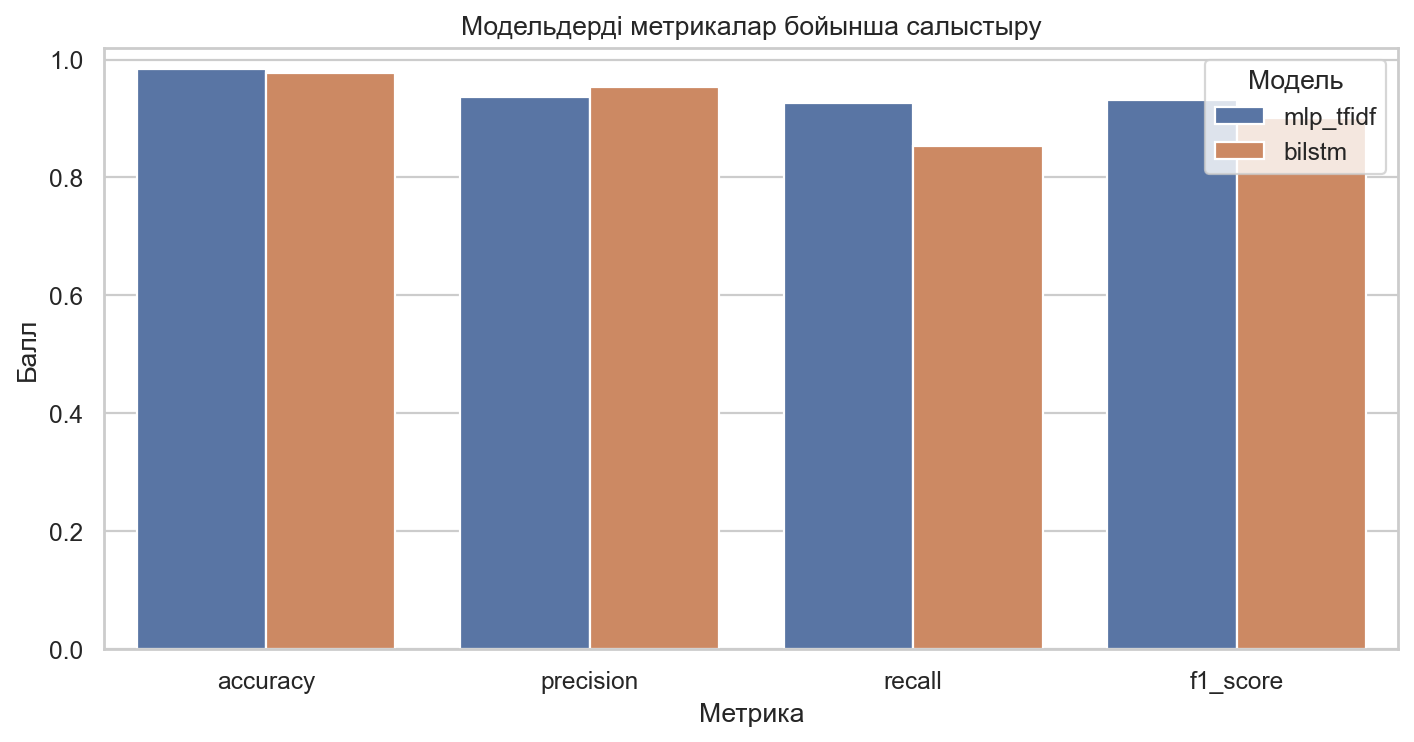

training_curves_mlp_tfidf.png


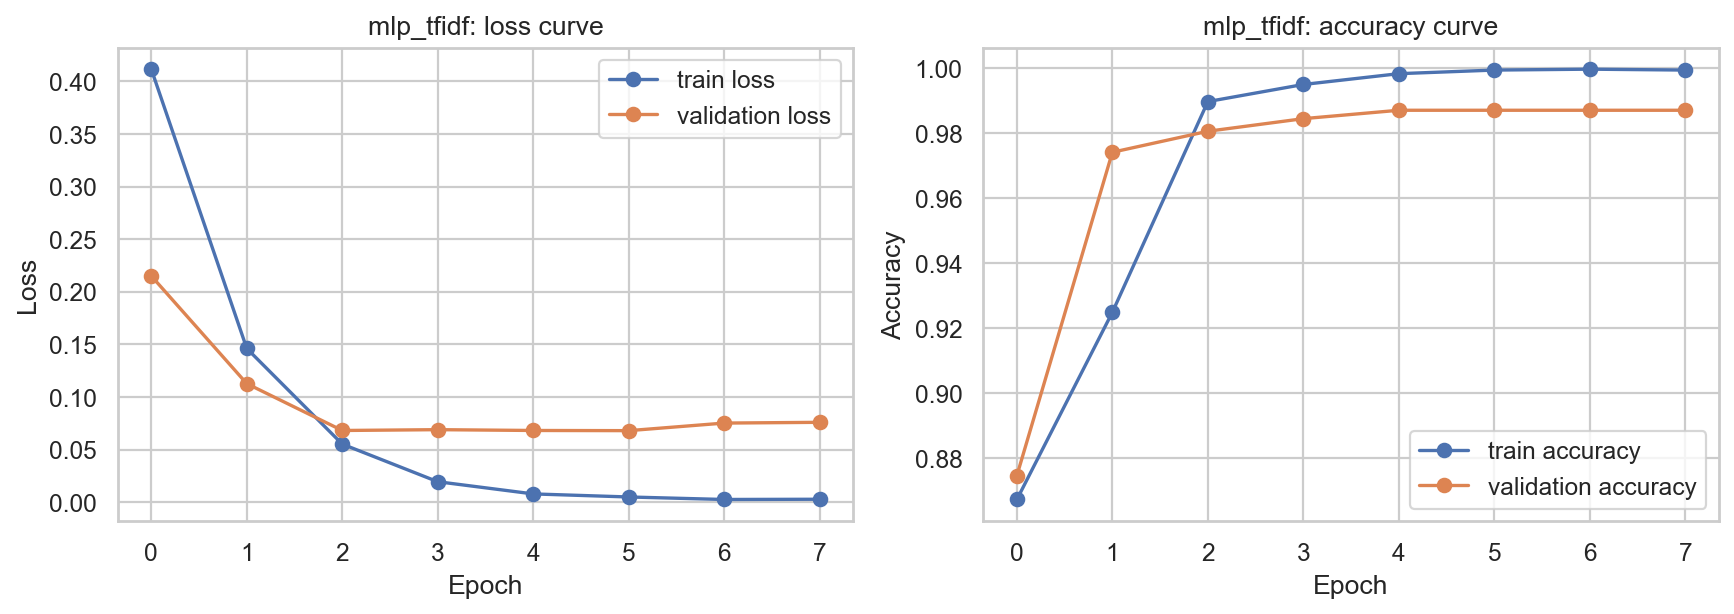

training_curves_bilstm.png


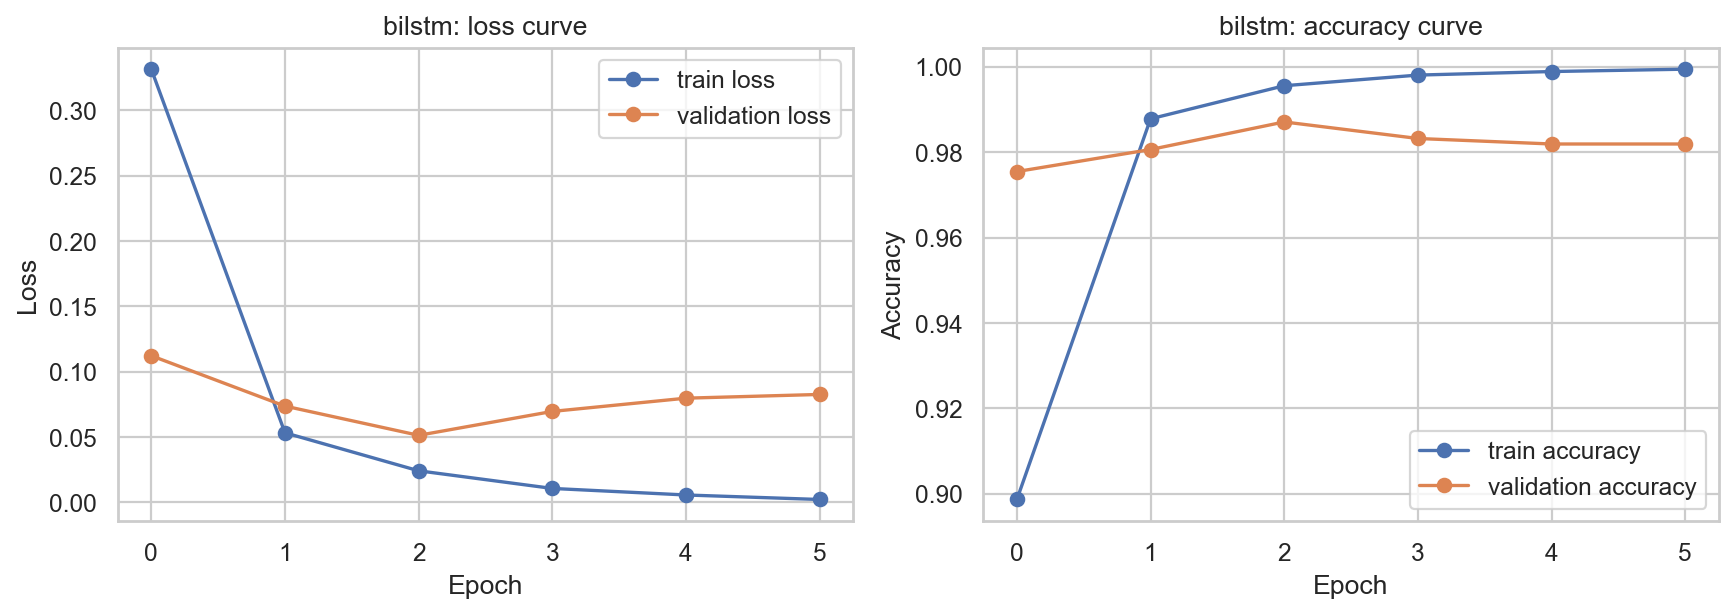

confusion_matrix_mlp_tfidf.png


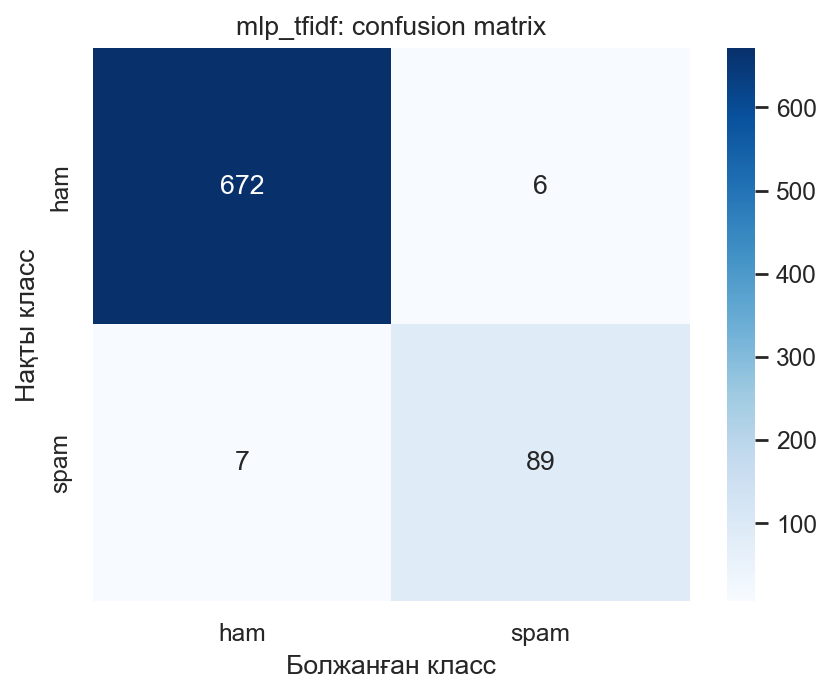

confusion_matrix_bilstm.png


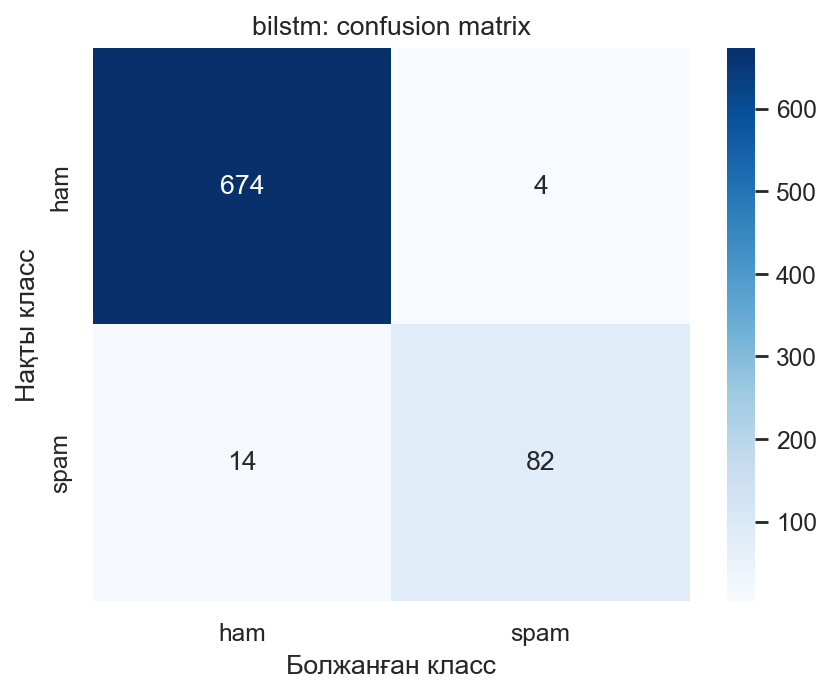

In [9]:
comparison_figures = [
    "model_comparison_metrics.png",
    "training_curves_mlp_tfidf.png",
    "training_curves_bilstm.png",
    "confusion_matrix_mlp_tfidf.png",
    "confusion_matrix_bilstm.png",
]

for figure_name in comparison_figures:
    print(figure_name)
    display(Image(filename=str(PROJECT_ROOT / "results" / "figures" / figure_name)))

## 7. Evaluation and analysis

?????? ??????? MLP + TF-IDF ?????? F1-score ??????? ???????? ?????. ?????? SMS spam ???????????????? ????? ??? ????? ?????? ????????? ??? ??????: ??????, ??????, ????, ??????? ????, ????? ?????? ??????? pattern-???. TF-IDF ??????? n-gram ?????????? ??????? ?????????.

BiLSTM ????????? ??? ???????? ?????? ?????, ????? ??? ??????? ????? ???? ??????? ???????????. ????????? BiLSTM ??????? ??????????? ????? ?????, overfitting ??????? ????????? ?????. ???????? ???? precision ???? ??????, ???? spam ??? ?????????? ???????????????? ???? ?????.

**????? ?????????:**

- MLP + TF-IDF: ??????, ???????, F1-score ??????.
- BiLSTM: sequence pattern ????????, ????? ????? ???????? ????????? recall ????????? ?????.
